# Etapas 2 e 3: Limpeza e Análise Exploratória (EDA)

Entrada: `imoveis_brutos.csv` (texto cru do notebook 01) → Saída: `imoveis_limpos.csv` + gráficos em `figs/`.

| Tarefa obrigatória (enunciado) | Onde |
|---|---|
| `"R$ 1.200.000"` → `1200000.0` | `limpar_preco` |
| `"75 m²"` → `75.0` | `primeiro_numero` |
| Valores ausentes | seção 2.3 |
| Outliers (IQR, k = 3) | seção 2.5 |
| `preco_m2 = preco / area_m2` | seção 2.5 |
| Histogramas, heatmap, scatter com reta, boxplot por bairro | seção 3 |

## Imports

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")
Path("figs").mkdir(exist_ok=True)

bruto = pd.read_csv("imoveis_brutos.csv", dtype=str)
bruto["lancamento"] = bruto["lancamento"] == "True"
print(bruto.shape)

(734, 14)


## Melhorando o Output

In [2]:
def formatar_numero_br(valor, casas=2):
    return f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def formatar_moeda_br(valor):
    return "Não informado" if pd.isna(valor) else f"R$ {formatar_numero_br(valor)}"


def exibir_imovel(imovel, titulo="RESUMO DO IMÓVEL"):
    linhas = [
        ("Bairro", imovel.get("bairro") or "Não informado"),
        ("Tipo", imovel.get("tipo") or "Não informado"),
        ("Preço", formatar_moeda_br(imovel.get("preco"))),
        ("Área", f"{formatar_numero_br(imovel['area_m2'], 1)} m²"
         if pd.notna(imovel.get("area_m2")) else "Não informada"),
        ("Preço por m²", formatar_moeda_br(imovel.get("preco_m2")) + "/m²"
         if pd.notna(imovel.get("preco_m2")) else "Não informado"),
        ("Quartos", f"{imovel['quartos']:.0f}" if pd.notna(imovel.get("quartos")) else "Não informado"),
        ("Banheiros", f"{imovel['banheiros']:.0f}" if pd.notna(imovel.get("banheiros")) else "Não informado"),
        ("Vagas de garagem", f"{imovel['vagas']:.0f}" if pd.notna(imovel.get("vagas")) else "Não informado"),
        ("Condomínio", formatar_moeda_br(imovel.get("condominio"))),
    ]
    conteudos = [f" {chave}: {valor}" for chave, valor in linhas]
    largura = max(len(titulo) + 2, *(len(c) + 1 for c in conteudos))

    print("╭" + "─" * largura + "╮")
    print("│" + titulo.center(largura) + "│")
    print("├" + "─" * largura + "┤")
    for conteudo in conteudos:
        print("│" + conteudo.ljust(largura) + "│")
    print("╰" + "─" * largura + "╯")


# Eixos em reais: 1500000 → "R$ 1,5 mi"
reais_mi = FuncFormatter(lambda v, _: f"R$ {formatar_numero_br(v / 1e6, 1)} mi")

# Etapa 2: Limpeza

## 2.1 Texto → número

In [3]:
def limpar_preco(valor):
    # 'R$ 1.200.000' → 1200000.0 | 'Sob consulta' → NaN
    if pd.isna(valor):
        return np.nan
    so_digitos = re.sub(r"[^\d]", "", str(valor))
    return float(so_digitos) if so_digitos else np.nan


def primeiro_numero(valor):
    # '75 m²' → 75.0 | '2 - 3' → 2.0 | None → NaN
    if pd.isna(valor):
        return np.nan
    achado = re.search(r"\d+", str(valor).replace(".", ""))   # tira o ponto de milhar antes
    return float(achado.group()) if achado else np.nan


def valor_mensal(valor):
    # Condomínio/IPTU: 'R$ 1.100' → 1100.0 | 'isento' → 0.0
    if pd.isna(valor):
        return np.nan
    return 0.0 if str(valor).strip().lower() == "isento" else limpar_preco(valor)


print(limpar_preco("R$ 1.200.000"), primeiro_numero("75 m²"), primeiro_numero("2 - 3"), valor_mensal("isento"))

1200000.0 75.0 2.0 0.0


## 2.2 Aplicando na tabela

Três decisões antes de converter:

- **Lançamentos** ("A partir de R$ ..."): o preço é o da unidade mais barata, não o de um imóvel específico → removidos.
- **Área em faixa** (`"26 - 57 m²"`): o anúncio cobre várias unidades e não dá para saber a qual área o preço se refere → removidos. Isso é diferente de `quartos = "2 - 3"`, em que pegar o menor número é uma escolha conservadora aceitável.
- **"Sob consulta"** vira `NaN` e sai no `dropna` abaixo.

In [4]:
df = bruto.copy()
passos = [("Coletados", len(df))]

df = df[~df["lancamento"] & ~df["preco"].str.contains("A partir", na=False)]
passos.append(("Sem lançamentos", len(df)))

df = df[~df["area_m2"].str.contains("-", na=False)]
passos.append(("Sem área em faixa", len(df)))

df["preco"] = df["preco"].apply(limpar_preco)
for coluna in ["area_m2", "quartos", "banheiros", "vagas"]:
    df[coluna] = df[coluna].apply(primeiro_numero)
for coluna in ["condominio", "iptu"]:
    df[coluna] = df[coluna].apply(valor_mensal)

df.info()

<class 'pandas.DataFrame'>
Index: 726 entries, 0 to 733
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              719 non-null    str    
 1   preco           726 non-null    float64
 2   condominio      725 non-null    float64
 3   iptu            725 non-null    float64
 4   area_m2         725 non-null    float64
 5   quartos         722 non-null    float64
 6   banheiros       725 non-null    float64
 7   vagas           541 non-null    float64
 8   bairro          726 non-null    str    
 9   bairro_anuncio  721 non-null    str    
 10  tipo            726 non-null    str    
 11  lancamento      726 non-null    bool   
 12  url             719 non-null    str    
 13  data_coleta     726 non-null    str    
dtypes: bool(1), float64(7), str(6)
memory usage: 80.1 KB


## 2.3 Valores ausentes

- **`vagas` vazio → 0.** No Plano Piloto isso tem explicação concreta: muitos prédios antigos das superquadras **não têm vaga privativa** (o carro fica sob os pilotis ou na rua), e o anúncio simplesmente omite o campo. Usar a média daria "1,7 vaga", que não existe.
- **Sem preço, área, quartos ou banheiros → a linha sai.** São as variáveis do modelo; imputar o próprio alvo (`preco`) seria inventar dado.

In [5]:
print("Ausentes ANTES:")
print(df[["preco", "area_m2", "quartos", "banheiros", "vagas"]].isna().sum())
print("\nVagas ausentes por tipo:", df.loc[df["vagas"].isna(), "tipo"].value_counts().to_dict())

df["vagas"] = df["vagas"].fillna(0)
df = df.dropna(subset=["preco", "area_m2", "quartos", "banheiros"])
passos.append(("Sem ausentes essenciais", len(df)))

Ausentes ANTES:
preco          0
area_m2        1
quartos        4
banheiros      1
vagas        185
dtype: int64

Vagas ausentes por tipo: {'apartamento': 152, 'kitnet': 22, 'casa': 11}


## 2.4 Duplicados

O notebook 01 já removeu repetidos pelo `id` do anúncio. Mas o **mesmo imóvel** costuma ser anunciado por **várias imobiliárias**, cada uma com seu `id`. Se todas as características batem (preço, área, quartos, banheiros, vagas, bairro, tipo), tratamos como o mesmo imóvel. Sem isso, o modelo "vê" o mesmo ponto duas vezes, e ele pode cair uma vez no treino e outra no teste (vazamento).

In [6]:
CARACTERISTICAS = ["preco", "area_m2", "quartos", "banheiros", "vagas", "bairro", "tipo"]
print(f"Duplicados por características: {df.duplicated(subset=CARACTERISTICAS).sum()}")
df = df.drop_duplicates(subset=CARACTERISTICAS)
passos.append(("Sem duplicados", len(df)))

Duplicados por características: 14


## 2.5 `preco_m2` e outliers (regra do IQR)

$$\text{IQR} = Q_3 - Q_1 \qquad \text{fica se } \; Q_1 - k\cdot\text{IQR} \;\le x\le\; Q_3 + k\cdot\text{IQR}, \quad k = 3$$

Aplicamos em `preco` e `area_m2`, como pede o enunciado, e também em `vagas`, porque há erros de digitação evidentes (um apartamento de 122 m² com **50 vagas**, outro com 16). Em `preco_m2` aplicamos na **escala log**, por um motivo que os dados mostram:

- `preco_m2` é muito assimétrico. Na escala normal, $Q_1 - 3\cdot\text{IQR}$ fica **negativo**, então a regra nunca remove nada por baixo.
- Mas há anúncios absurdos por baixo: apartamento na Asa Sul a **R$ 69 mil** (R$ 1.210/m²) e "casas" de 1.000 m² a R$ 350 mil (na verdade, terrenos). Na escala log, a distância é medida em **proporção** ("5× mais barato que o típico"), e esses pontos caem fora.

> `preco_m2` serve para **análise** (comparar bairros, achar anúncios estranhos). Ele **nunca** entra como preditor do preço, porque é calculado a partir do próprio preço (*data leakage*).

In [7]:
def remover_outliers_iqr(tabela, coluna, k=3, log=False):
    valores = np.log(tabela[coluna]) if log else tabela[coluna]
    q1, q3 = valores.quantile([0.25, 0.75])
    iqr = q3 - q1
    dentro = valores.between(q1 - k * iqr, q3 + k * iqr)       # máscara True/False
    inferior, superior = q1 - k * iqr, q3 + k * iqr
    if log:
        inferior, superior = np.exp(inferior), np.exp(superior)
    escala = " (escala log)" if log else ""
    print(f"{coluna}{escala}: faixa aceita [{formatar_numero_br(inferior, 0)}, {formatar_numero_br(superior, 0)}]"
          f" → removendo {(~dentro).sum()}")
    return tabela[dentro]


df["preco_m2"] = df["preco"] / df["area_m2"]
for coluna in ["preco", "area_m2", "vagas"]:
    df = remover_outliers_iqr(df, coluna)
df = remover_outliers_iqr(df, "preco_m2", log=True)
passos.append(("Sem outliers", len(df)))

preco: faixa aceita [-5.183.500, 8.433.250] → removendo 18
area_m2: faixa aceita [-432, 688] → removendo 32
vagas: faixa aceita [-6, 8] → removendo 6
preco_m2 (escala log): faixa aceita [2.949, 59.671] → removendo 8


### Resumo da limpeza e arquivo final

In [8]:
resumo = pd.DataFrame(passos, columns=["etapa", "imóveis"])
resumo["removidos"] = -resumo["imóveis"].diff().fillna(0).astype(int)
display(resumo)

COLUNAS_FINAIS = ["id", "preco", "area_m2", "quartos", "banheiros", "vagas", "bairro", "tipo",
                  "preco_m2", "condominio", "iptu", "bairro_anuncio", "url", "data_coleta"]
df = df[COLUNAS_FINAIS].reset_index(drop=True)
df.to_csv("imoveis_limpos.csv", index=False, encoding="utf-8-sig")
print(f"💾 {len(df)} imóveis salvos em imoveis_limpos.csv")
print(pd.crosstab(df["bairro"], df["tipo"], margins=True, margins_name="Total"))

,etapa,imóveis,removidos
0,Coletados,734,0
1,Sem lançamentos,731,3
2,Sem área em faixa,726,5
3,Sem ausentes essenciais,720,6
4,Sem duplicados,706,14
5,Sem outliers,642,64


💾 642 imóveis salvos em imoveis_limpos.csv
tipo           apartamento  casa  cobertura  kitnet  Total
bairro                                                    
Asa Norte              189     7         10      19    225
Asa Sul                111    24          1       4    140
Cruzeiro Novo           13     0          0       0     13
Lago Norte              21    42          0       5     68
Lago Sul                 0    25          0       1     26
Noroeste                72     1          8       0     81
Octogonal                3     0          0       0      3
Sudoeste                66     0          2      18     86
Total                  475    99         21      47    642


### Sobre o condomínio

O condomínio seria um ótimo preditor (ele acompanha o padrão do prédio), mas olhe a proporção de "isento" nos apartamentos: prédio residencial sem condomínio praticamente não existe. Na prática, "isento" significa **"o anunciante não preencheu"**. Por isso `condominio` e `iptu` ficam no CSV, mas **fora do modelo**. É uma limitação que vale citar no relatório.

In [9]:
print("% de anúncios com condomínio 'isento' (= 0) por tipo:")
print((df.assign(isento=df["condominio"].eq(0)).groupby("tipo")["isento"].mean() * 100).round(1))

% de anúncios com condomínio 'isento' (= 0) por tipo:
tipo
apartamento    28.6
casa           94.9
cobertura      19.0
kitnet         25.5
Name: isento, dtype: float64


# Etapa 3: Análise Exploratória (EDA)

## 3.1 Estatística descritiva

In [10]:
numericas = ["preco", "area_m2", "quartos", "banheiros", "vagas", "preco_m2"]
df[numericas].describe().round(1)

,preco,area_m2,quartos,banheiros,vagas,preco_m2
count,642.0,642.0,642.0,642.0,642.0,642.0
mean,1664655.3,144.9,2.5,2.8,1.5,13746.8
std,1314075.9,143.6,1.3,1.9,1.5,4666.5
min,190000.0,19.0,1.0,1.0,0.0,3003.8
25%,633500.0,45.0,1.0,1.0,0.0,10833.3
50%,1290000.0,95.0,3.0,2.0,1.0,13972.7
75%,2296750.0,182.8,3.0,4.0,2.0,16492.6
max,6800000.0,687.0,8.0,8.0,8.0,29011.6


In [11]:
print("Mediana do preço por m², por bairro:")
print(df.groupby("bairro")["preco_m2"].median().sort_values(ascending=False).round(0))

exibir_imovel(df.loc[df["preco_m2"].idxmin()], titulo="MENOR PREÇO/m² DA AMOSTRA")
exibir_imovel(df.loc[df["preco_m2"].idxmax()], titulo="MAIOR PREÇO/m² DA AMOSTRA")

Mediana do preço por m², por bairro:
bairro
Noroeste         16885.0
Sudoeste         15397.0
Asa Norte        14286.0
Octogonal        13636.0
Asa Sul          13587.0
Cruzeiro Novo     9365.0
Lago Norte        8157.0
Lago Sul          7030.0
Name: preco_m2, dtype: float64
╭──────────────────────────────╮
│  MENOR PREÇO/m² DA AMOSTRA   │
├──────────────────────────────┤
│ Bairro: Lago Norte           │
│ Tipo: casa                   │
│ Preço: R$ 799.000,00         │
│ Área: 266,0 m²               │
│ Preço por m²: R$ 3.003,76/m² │
│ Quartos: 2                   │
│ Banheiros: 4                 │
│ Vagas de garagem: 4          │
│ Condomínio: R$ 0,00          │
╰──────────────────────────────╯
╭───────────────────────────────╮
│   MAIOR PREÇO/m² DA AMOSTRA   │
├───────────────────────────────┤
│ Bairro: Sudoeste              │
│ Tipo: apartamento             │
│ Preço: R$ 4.990.000,00        │
│ Área: 172,0 m²                │
│ Preço por m²: R$ 29.011,63/m² │
│ Quartos: 4            

## 3.2 Histogramas

Preço de imóvel quase sempre tem **cauda longa à direita** (poucos imóveis caríssimos). O terceiro gráfico mostra o `log(preco)`, bem mais simétrico, que é o argumento para testar `log(preco)` no notebook 03.

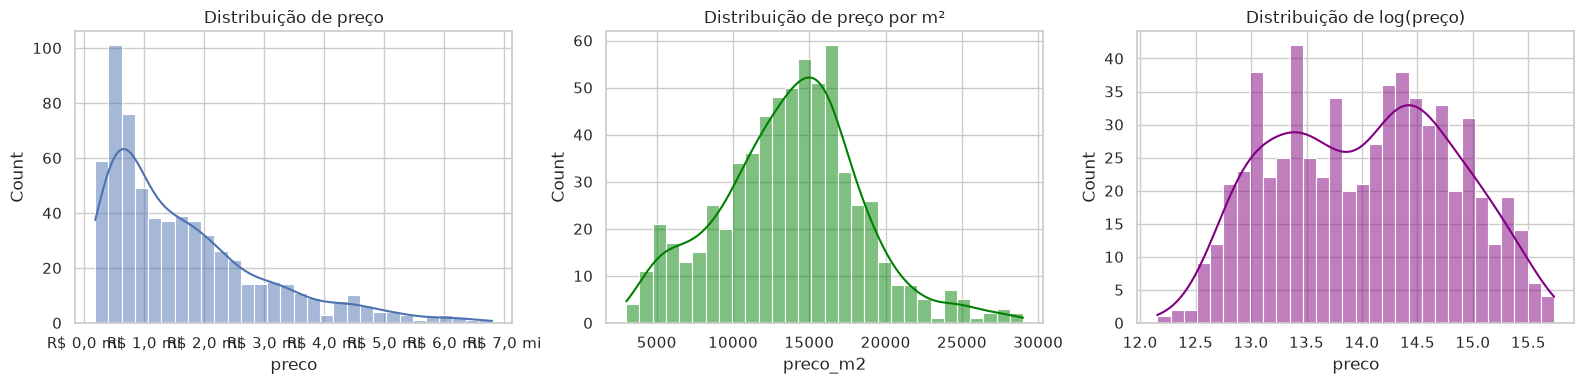

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["preco"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribuição de preço")
axes[0].xaxis.set_major_formatter(reais_mi)
sns.histplot(df["preco_m2"], bins=30, kde=True, ax=axes[1], color="green")
axes[1].set_title("Distribuição de preço por m²")
sns.histplot(np.log(df["preco"]), bins=30, kde=True, ax=axes[2], color="purple")
axes[2].set_title("Distribuição de log(preço)")
plt.tight_layout()
plt.savefig("figs/histogramas.png", dpi=150)
plt.show()

## 3.3 Matriz de correlação

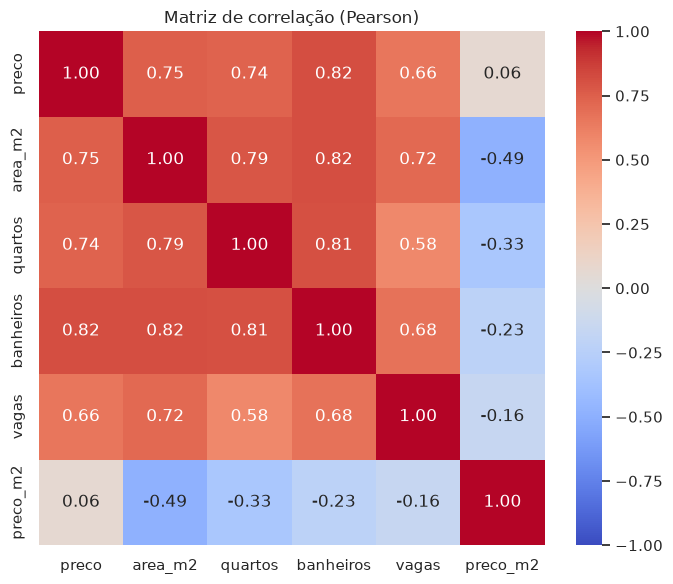

banheiros    0.82
area_m2      0.75
quartos      0.74
vagas        0.66
preco_m2     0.06
Name: preco, dtype: float64


In [13]:
plt.figure(figsize=(7, 6))
sns.heatmap(df[numericas].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação (Pearson)")
plt.tight_layout()
plt.savefig("figs/correlacao.png", dpi=150)
plt.show()

print(df[numericas].corr()["preco"].drop("preco").sort_values(ascending=False).round(2))

## 3.4 Área × preço com reta de tendência

À esquerda, a reta da **Regressão Linear Simples** (`regplot`) sobre todos os imóveis. À direita, **uma reta por tipo**: casas (terreno grande, sobretudo nos Lagos) seguem outra relação área × preço que apartamentos. Misturar grupos distorce a reta, e por isso `tipo` e `bairro` entram no modelo.

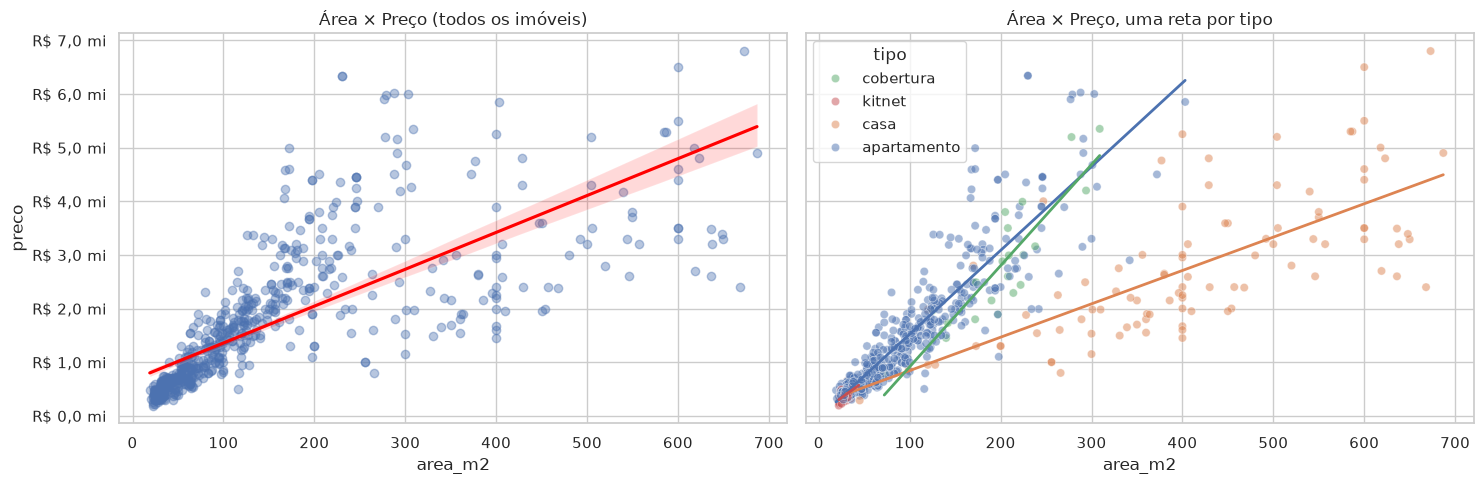

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.regplot(data=df, x="area_m2", y="preco", ax=axes[0],
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
axes[0].set_title("Área × Preço (todos os imóveis)")

cores = dict(zip(sorted(df["tipo"].unique()), sns.color_palette()))   # mesma cor no ponto e na reta
sns.scatterplot(data=df, x="area_m2", y="preco", hue="tipo", palette=cores, alpha=0.5, ax=axes[1])
for tipo, grupo in df.groupby("tipo"):
    if len(grupo) >= 10:                                               # reta com poucos pontos não diz nada
        sns.regplot(data=grupo, x="area_m2", y="preco", scatter=False, ci=None, ax=axes[1],
                    color=cores[tipo], line_kws={"lw": 2})
axes[1].set_title("Área × Preço, uma reta por tipo")
for ax in axes:
    ax.yaxis.set_major_formatter(reais_mi)
plt.tight_layout()
plt.savefig("figs/scatter_area_preco.png", dpi=150)
plt.show()

In [15]:
# Versão interativa: passe o mouse nos pontos para ver bairro, quartos e link do anúncio
fig = px.scatter(df, x="area_m2", y="preco", color="tipo", trendline="ols",
                 hover_data=["bairro", "quartos", "banheiros", "vagas", "url"],
                 title="Área × Preço (interativo)")
fig.write_html("figs/scatter_interativo.html")
fig.show()

## 3.5 Boxplot por bairro (top 10 em número de anúncios)

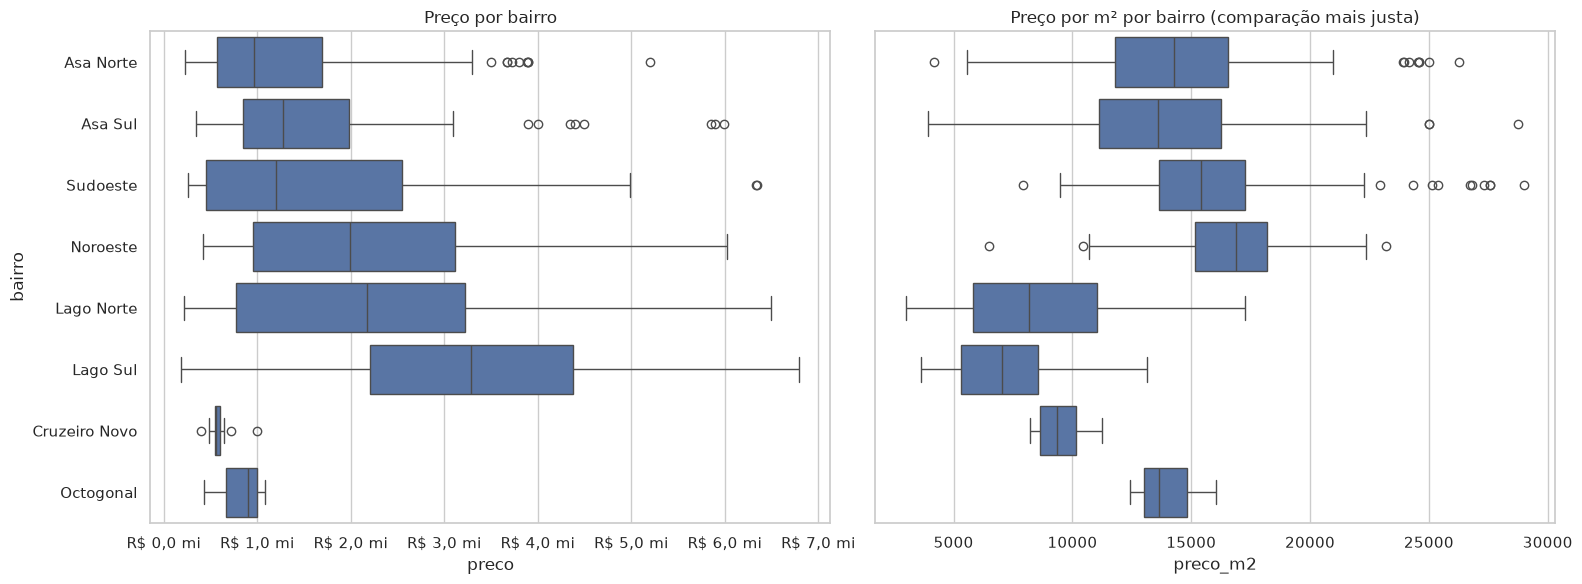

In [16]:
top10 = df["bairro"].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.boxplot(data=df[df["bairro"].isin(top10)], x="preco", y="bairro", order=top10, ax=axes[0])
axes[0].set_title("Preço por bairro")
axes[0].xaxis.set_major_formatter(reais_mi)
sns.boxplot(data=df[df["bairro"].isin(top10)], x="preco_m2", y="bairro", order=top10, ax=axes[1])
axes[1].set_title("Preço por m² por bairro (comparação mais justa)")
plt.tight_layout()
plt.savefig("figs/boxplot_bairros.png", dpi=150)
plt.show()

## 3.6 Pergunta para reflexão

> *Quais variáveis parecem mais correlacionadas com o preço? A relação é linear?*

Resposta com os números da coleta de **27/09/2026** (642 imóveis após a limpeza; ao coletar de novo, confira com as saídas acima):

1. **Ranking de correlação com o preço:** banheiros (0,82) > área (0,75) > quartos (0,74) > vagas (0,66). Banheiros "ganha" da área porque resume o **padrão** do imóvel: imóveis de alto padrão têm suíte em todos os quartos.
2. **As preditoras são correlacionadas entre si** (área × quartos × banheiros). Por isso o VIF no notebook 03 é obrigatório.
3. **A relação é linear?** Só em parte:
   - **Dentro de cada tipo**, área × preço é razoavelmente reta (gráfico da direita na 3.4).
   - Mas **casas e apartamentos seguem retas diferentes**: casa nos Lagos custa bem menos por m² (terreno grande) que apartamento no Noroeste. Uma reta única mistura os grupos, e por isso `tipo` e `bairro` entram no modelo.
   - A dispersão **aumenta** com a área (formato de funil), e o preço tem cauda longa à direita (histograma). As duas coisas pedem a **escala log**, testada no notebook 03.
4. `preco_m2` quase não se correlaciona com o preço (0,06). É esperado: ele mede **localização e padrão**, não tamanho. Serve para comparar bairros (mediana: Noroeste > Sudoeste > Asa Norte ≈ Asa Sul > Cruzeiro > Lagos), não para prever.